In [509]:
#import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go



In [510]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = [
     "observations"
]
HIDDEN_LAYERS = [32, 16]  # Increase model complexity with more layers
ACTIVATION = nn.ReLU
DROPOUT = 0.3  # Increase dropout rate to reduce overfitting
LOSS_FN = nn.MSELoss
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.0001  # Reduce learning rate for more stable training
WEIGHT_DECAY = 0.001  # Increase weight decay for regularization
EPOCHS = 6000  # Reduce epochs to prevent overfitting
BATCH_SIZE = 32  # Increase batch size for faster training
SEED = 42
TEST_SIZE = 0.2
N_SAMPLES = 300  # Simulate data for 30 days
BEST_LOSS = float('inf')  # Start with a very high loss
PATIENCE = 100  # Reduce patience to stop earlier if no improvement
PATIENCE_COUNTER = 0 # Counter for early stopping


In [511]:
# Set a random seed for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create a date range starting from January 1, 2025
last_observed = pd.date_range(start="2025-01-01", periods=N_SAMPLES, freq="D")

# Generate random observations between 20 and 200
observations = np.random.randint(20, 200, size=N_SAMPLES)

# Add some noise to the observations
noise = np.random.normal(0, 10, size=N_SAMPLES)  # Mean 0, Std Dev 10
observations = observations + noise

# Create the DataFrame
df = pd.DataFrame({
    "last_observed": last_observed,
    "observations": observations
})

# Shift the observations by 1 day
df['observations'] = df['observations'].shift(-1)
# Drop the first row with NaN value
df.dropna(inplace=True)

# Display the first few rows of the DataFrame
df.head()

# Keep the plots
fig = go.Figure()
fig.add_trace(go.Scatter(x=last_observed[:200], y=observations[:200], mode='lines', name='Observations', opacity=0.7))

fig.update_layout(
    title="Observations Over Time",
    xaxis_title="Date",
    yaxis_title="Observations",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()


In [512]:
df.head(40)

,last_observed,observations
0,2025-01-01,202.411520
1,2025-01-02,114.766908
2,2025-01-03,42.271832
3,2025-01-04,126.130019
4,2025-01-05,105.535341
5,2025-01-06,37.353432
6,2025-01-07,149.201692
7,2025-01-08,147.256673
8,2025-01-09,85.428424
9,2025-01-10,96.291075


In [513]:
# ----------------------------
# Preprocessing
# ----------------------------
def preprocess_data(df, features, target_column, batch_size, test_size=0.2, seed=42, time_series=True):
    # Scale the input features
    scaler = MinMaxScaler()
    # Exclude datetime columns from scaling
    numeric_features = df[features].select_dtypes(include=[np.number])
    X = scaler.fit_transform(numeric_features)
    y = df[target_column].values.reshape(-1, 1)

    # Split without shuffling for time series data
    split_index = int(len(df) * (1 - test_size))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
        
    # Convert to tensors
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    # Create DataLoader
    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, X_test, y_test, X_tensor, y_tensor


#call the function
train_loader, X_test, y_test, X_tensor, y_tensor = preprocess_data(df, FEATURES, "observations", BATCH_SIZE)

In [514]:
# ----------------------------
# Customizable MLP Model
# ----------------------------
class NetTrafficRegressor(nn.Module): # create a class for the model
    def __init__(self, input_dim, hidden_dims, activation, dropout):
        super().__init__()
        layers = [] # create a list to store the layers
        dims = [input_dim] + hidden_dims # create a list of dimensions for the layers
        for i in range(len(dims) - 1): # loop through the dimensions to create the layers
            layers.append(nn.Linear(dims[i], dims[i + 1])) # add a linear layer
            layers.append(activation()) # add the activation function after the linear layer for non-linearity
            if dropout > 0: # add dropout if the dropout rate is greater than 0 to prevent overfitting
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers) # create the model as a sequential model

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if cuda is available and use it if it is available otherwise use cpu


model = NetTrafficRegressor(
    input_dim=len(FEATURES), # input dimension is the number of features
    hidden_dims=HIDDEN_LAYERS, # hidden layers are the hidden layers specified in the hyperparameters
    activation=ACTIVATION, # activation function is the activation function specified in the hyperparameters
    dropout=DROPOUT # dropout rate is the dropout rate specified in the hyperparameters
).to(device)

model

NetTrafficRegressor(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [515]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 000 | Train Loss: 14748.0872 | Test Loss: 17886.8105
Epoch 100 | Train Loss: 14749.7506 | Test Loss: 17434.1582
Epoch 200 | Train Loss: 13462.9330 | Test Loss: 15883.3770
Epoch 300 | Train Loss: 10799.1910 | Test Loss: 13017.8643
Epoch 400 | Train Loss: 7867.0556 | Test Loss: 9423.4121
Epoch 500 | Train Loss: 5232.6244 | Test Loss: 5792.6479
Epoch 600 | Train Loss: 3274.2231 | Test Loss: 3089.8640
Epoch 700 | Train Loss: 2740.1709 | Test Loss: 1763.6135
Epoch 800 | Train Loss: 2191.3890 | Test Loss: 1310.2821
Epoch 900 | Train Loss: 2108.0759 | Test Loss: 1170.4344
Epoch 1000 | Train Loss: 2057.2452 | Test Loss: 1093.9000
Epoch 1100 | Train Loss: 2106.1856 | Test Loss: 1016.9152
Epoch 1200 | Train Loss: 2184.7134 | Test Loss: 942.5780
Epoch 1300 | Train Loss: 1965.3444 | Test Loss: 872.1290
Epoch 1400 | Train Loss: 1986.9643 | Test Loss: 800.9904
Epoch 1500 | Train Loss: 1731.3015 | Test Loss: 739.8340
Epoch 1600 | Train Loss: 1613.7633 | Test Loss: 680.7101
Epoch 1700 | Train Lo

/Users/jaytlinaskew/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.



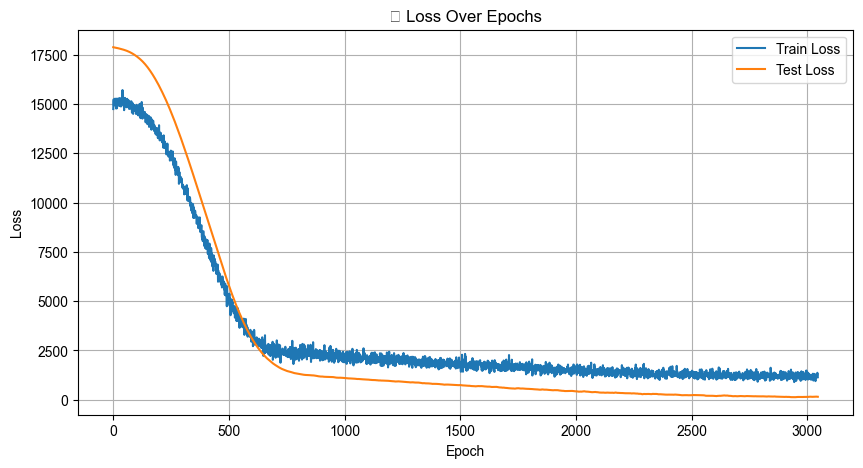

In [516]:
# ----------------------------
# Training Loop + Evaluation
# ----------------------------

train_losses = [] # create a list to store the training losses
test_losses = [] # create a list to store the test losses

for epoch in range(EPOCHS): # loop through the epochs for training the model specified in the hyperparameters
    model.train()
    running_loss = 0.0 # initialize the running loss to 0 for each epoch to calculate the average loss
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device) # move the data to the device (cuda or cpu)
        preds = model(xb)
        loss = loss_fn(preds, yb)
        optimizer.zero_grad() # zero the gradients to prevent accumulation of gradients
        loss.backward() # backpropagate the loss to calculate the gradients of the model parameters
        optimizer.step() # update the model parameters using the optimizer
        running_loss += loss.item() # add the loss to the running loss

    # Average train loss
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate on full dataset (or you could use a test loader)
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test.to(device))
        test_loss = loss_fn(y_pred_test.cpu(), y_test).item()
        test_losses.append(test_loss)
        
        if test_loss < BEST_LOSS:
            BEST_LOSS = test_loss
            PATIENCE_COUNTER = 0  # reset if loss improves
        else:
            PATIENCE_COUNTER += 1
        if PATIENCE_COUNTER >= PATIENCE:
            print(f"Early stopping at epoch {EPOCHS} — no improvement for {PATIENCE} epochs.")
            break

    # Logging
    if epoch % 100 == 0 or epoch == EPOCHS - 1: # print the loss every 20 epochs
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("📉 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.rcParams['font.family'] = 'Arial' 
plt.legend()
plt.grid(True)
plt.show()


In [517]:
# ----------------------------
# Evaluation
# ----------------------------
model.eval()
with torch.no_grad(): # turn off gradient tracking for evaluation to save memory and computation time
    y_pred = model(X_test.to(device)).cpu().numpy() # predict the target values using the model
    y_true = y_test.cpu().numpy() # get the true target values from the tensor

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.array(df["last_observed"][:200]), y=y_true[:200].flatten(), mode='lines', name='True', opacity=0.7))
fig.add_trace(go.Scatter(x=np.array(df["last_observed"][:200]), y=y_pred[:200].flatten(), mode='lines', name='Predicted', opacity=0.7))

fig.update_layout(
    title="Next observation Prediction By Date",
    xaxis_title="Date",
    yaxis_title="Number of Observations",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()


In [518]:
# Compute average accuracy (1 - MAPE)
accuracy = 1 - np.mean(np.abs((y_true - y_pred) / y_true))
print(f"Average Accuracy: {accuracy:.2%}")

# Compare to previous best accuracy
if 'prev_accuracy' not in locals():
    prev_accuracy = 0  # Initialize prev_accuracy if not already defined

if accuracy > prev_accuracy:
    best_accuracy = accuracy
    print(f"New best accuracy: {best_accuracy:.2%}")
    # Update stored accuracy
    prev_accuracy = accuracy
else:
    print(f"Accuracy did not improve (Best: {prev_accuracy:.2%})")



# Save the actual and predicted values to a dataframe
pred_df = pd.DataFrame({
    "timestamp": df["last_observed"].values[:len(y_pred)],
    "actual_observed": y_true.flatten(),
    "predicted_observed": y_pred.flatten()
})

# Add the difference between actual and predicted values
pred_df["difference"] = pred_df["actual_observed"] - pred_df["predicted_observed"]

#print the first 10 rows of the dataframe
pred_df.head(10)

Average Accuracy: 92.16%
Accuracy did not improve (Best: 95.48%)


,timestamp,actual_observed,predicted_observed,difference
0,2025-01-01,102.658859,97.018700,5.640160
1,2025-01-02,38.776768,42.570320,-3.793552
2,2025-01-03,166.323135,150.913788,15.409348
3,2025-01-04,101.515137,96.043877,5.471260
4,2025-01-05,146.511520,134.395477,12.116043
5,2025-01-06,80.156746,77.839561,2.317184
6,2025-01-07,143.792969,132.078369,11.714600
7,2025-01-08,21.675184,28.620899,-6.945715
8,2025-01-09,168.607483,152.700058,15.907425
9,2025-01-10,84.553406,81.586952,2.966454


In [519]:
# Define new parameters as a dictionary
new_params = {
    "Hidden Layers": [HIDDEN_LAYERS],
    "Activation Function": [ACTIVATION.__name__],
    "Dropout Rate": [DROPOUT],
    "Loss Function": [LOSS_FN.__name__],
    "Optimizer": [OPTIMIZER_FN.__name__],
    "Learning Rate": [LEARNING_RATE],
    "Weight Decay": [WEIGHT_DECAY],
    "Epochs": [EPOCHS],
    "Batch Size": [BATCH_SIZE],
    "Seed": [SEED],
    "Test Size": [TEST_SIZE],
    "N_Samples": [N_SAMPLES],
    "Best Loss": [BEST_LOSS],
    "Patience": [PATIENCE],
    "Patience Counter": [PATIENCE_COUNTER],
    "Average Accuracy": accuracy,  # Keep as float for sorting
    "Average Accuracy (%)": f"{round(accuracy * 100, 2)}%"  # Display version

}

# Convert the dictionary to a DataFrame
new_params_df = pd.DataFrame(new_params)

# Initialize params as an empty DataFrame if it doesn't exist
if 'params' not in locals():
    params = pd.DataFrame()

# Append the new parameters to the existing DataFrame
params = pd.concat([params, new_params_df], ignore_index=True).sort_values(by="Average Accuracy", ascending=False).reset_index(drop=True)

# Print the updated DataFrame
params

,Hidden Layers,Activation Function,Dropout Rate,Loss Function,Optimizer,Learning Rate,Weight Decay,Epochs,Batch Size,Seed,Test Size,N_Samples,Best Loss,Patience,Patience Counter,Average Accuracy,Average Accuracy (%)
0,"[32, 16]",ReLU,0.2,MSELoss,Adam,0.0001,0.0010,6000,32,42,0.2,300,3.401460e+01,100,100,0.954759,95.48%
1,"[32, 16]",ReLU,0.2,MSELoss,Adam,0.0001,0.0010,6000,32,42,0.2,400,3.139285e+01,100,100,0.947958,94.8%
2,"[32, 16]",ReLU,0.2,MSELoss,Adam,0.0001,0.0010,6000,32,42,0.2,500,3.370067e+01,100,100,0.947365,94.74%
3,"[32, 16]",ReLU,0.2,MSELoss,Adam,0.0001,0.0001,6000,32,42,0.2,400,3.552983e+01,100,100,0.946288,94.63%
4,"[32, 16]",ReLU,0.2,MSELoss,Adam,0.0001,0.0010,6000,32,42,0.2,1000,2.284269e+01,100,100,0.934876,93.49%
5,"[32, 16]",ReLU,0.3,MSELoss,Adam,0.0001,0.0010,6000,32,42,0.2,300,1.244531e+02,100,100,0.921572,92.16%
6,"[32, 16]",ReLU,0.4,MSELoss,Adam,0.0001,0.0001,6000,32,42,0.2,400,1.948145e+02,100,100,0.911671,91.17%
7,"[32, 16]",ReLU,0.3,MSELoss,Adam,0.0001,0.0001,6000,32,42,0.2,400,1.078971e+02,100,100,0.908559,90.86%
8,"[32, 16]",ReLU,0.2,MSELoss,Adam,0.0001,0.0010,6000,32,42,0.2,2000,2.591339e+01,100,100,0.903159,90.32%
9,"[32, 16]",ReLU,0.4,MSELoss,Adam,0.0001,0.0001,6000,32,42,0.2,400,2.118515e+02,100,100,0.902073,90.21%
